<a href="https://colab.research.google.com/github/SakshiiRajputt/vitalsense/blob/main/FINAL_AD_MODELS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Colab cell 1: Install / upgrade required packages
# Run this cell first (may take a few minutes).
!pip install --upgrade pip
# Torch is typically installed on Colab; installing a compatible release if needed:
import sys
print("Python version:", sys.version)
!pip install torch torchvision --quiet
!pip install nibabel nilearn scikit-learn pandas tqdm matplotlib seaborn joblib shap --quiet
# Note: shap can be slow to install; this installs CPU version. If this errors, retry installing shap separately.
print("Packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 23.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Packages installed.


In [ ]:
# Colab cell 2: Mount Google Drive and set paths
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# EDIT THESE PATHS if your Drive path differs:
DRIVE_BASE = "/content/drive/MyDrive"  # usually MyDrive
# The folder you gave: replace if different
DATA_FOLDER_IN_DRIVE = "1cX8ouJH9IchAAPXGcZ3NbiIXiHbPuAY"
# Note: your link is a 'folder id'; if you put the dataset under MyDrive/<someFolder> use that instead.
# If your uploaded/unzipped data is directly at MyDrive/PROCESSED_Data or similar, set below:
# Example final root:
DATA_ROOT = f"/content/drive/MyDrive/PROCESSED_Data"  # <-- change if your unzipped folder is elsewhere
CSV_PATH = "/content/drive/MyDrive/alzheimers_disease_data.csv"  # change to actual csv path in your Drive

# Output folder (will be created on Drive so you keep results)
OUT_DIR = "/content/drive/MyDrive/alz_outputs"
import os
os.makedirs(OUT_DIR, exist_ok=True)
print("OUT_DIR:", OUT_DIR)
print("If your data is zipped in Drive, unzip it below (next cell).")

Mounted at /content/drive
OUT_DIR: /content/drive/MyDrive/alz_outputs
If your data is zipped in Drive, unzip it below (next cell).


In [ ]:
from google.colab import drive
drive.flush_and_unmount()

Drive not mounted, so nothing to flush and unmount.


In [ ]:

# FIXED Google Drive mount cell for Colab
from google.colab import drive
import os
import shutil

mountpoint = "/content/drive"

# 1 — If '/content/drive' exists but is NOT a mount, delete it
if os.path.exists(mountpoint) and not os.path.ismount(mountpoint):
    print("Removing stale /content/drive directory...")
    shutil.rmtree(mountpoint)

# 2 — Create an empty directory for mounting
os.makedirs(mountpoint, exist_ok=True)

# 3 — Now safely mount
drive.mount(mountpoint, force_remount=True)

print("Drive mounted successfully!")

Mounted at /content/drive
Drive mounted successfully!


In [ ]:
DATA_DIR = "/content/drive/MyDrive/PROCESSED_Data"
classes = ["AD", "MCI", "CN"]


Loading CSV...
CSV shape: (2149, 35)
Numeric: ['Age', 'MMSE', 'BMI', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']
Categorical: ['Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'DoctorInCharge']
Processed X shape: (2149, 8639)
Preprocessor saved.
Training XGBoost...

FINAL TEST ACCURACY: 0.9534883720930233

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       278
           1       0.95      0.92      0.93       152

    accuracy                           0.95       430
   macro avg       0.95   

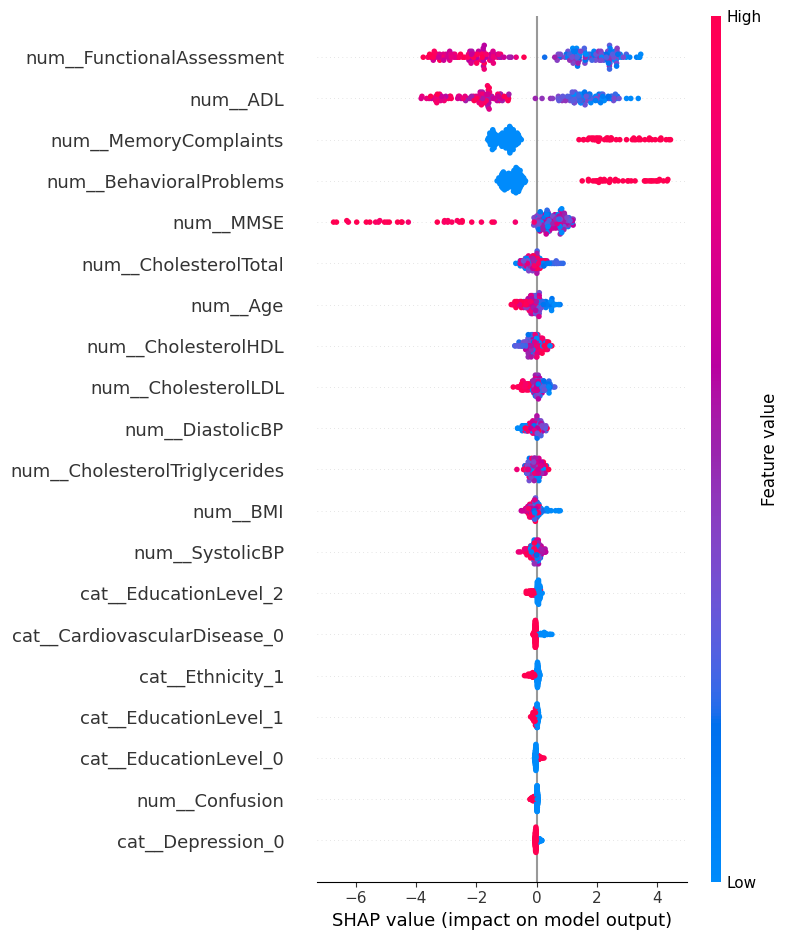

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import shap
import joblib
import xgboost as xgb
import json
import re

# ===========================
# PATHS
# ===========================
CSV_PATH = "/content/drive/MyDrive/alzheimers_disease_data.csv"
OUT_DIR = "/content/drive/MyDrive/alz_text_model_xgboost"
os.makedirs(OUT_DIR, exist_ok=True)

print("Loading CSV...")
df = pd.read_csv(CSV_PATH)
print("CSV shape:", df.shape)

# ===========================
# FEATURES & TARGET
# ===========================
TARGET = "Diagnosis"

NUMERIC = [
    'Age','MMSE','BMI','SystolicBP','DiastolicBP','CholesterolTotal',
    'CholesterolLDL','CholesterolHDL','CholesterolTriglycerides',
    'FunctionalAssessment','MemoryComplaints','BehavioralProblems',
    'ADL','Confusion','Disorientation','PersonalityChanges',
    'DifficultyCompletingTasks','Forgetfulness'
]

CATEGORICAL = [
    'Gender','Ethnicity','EducationLevel','Smoking','AlcoholConsumption',
    'PhysicalActivity','DietQuality','SleepQuality','FamilyHistoryAlzheimers',
    'CardiovascularDisease','Diabetes','Depression','HeadInjury','Hypertension',
    'DoctorInCharge'
]

# Keeping only real columns
NUMERIC = [c for c in NUMERIC if c in df.columns]
CATEGORICAL = [c for c in CATEGORICAL if c in df.columns]

print("Numeric:", NUMERIC)
print("Categorical:", CATEGORICAL)

# ===========================
# PREPROCESSING
# ===========================
df[NUMERIC] = df[NUMERIC].fillna(df[NUMERIC].median())
for c in CATEGORICAL:
    df[c] = df[c].fillna("missing")

X = df[NUMERIC + CATEGORICAL]
y = df[TARGET].astype(int)

# One-hot encode
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", ohe, CATEGORICAL)
])

X_processed = preprocessor.fit_transform(X)
print("Processed X shape:", X_processed.shape)

joblib.dump(preprocessor, f"{OUT_DIR}/preprocessor.joblib")
print("Preprocessor saved.")

# ===========================
# TRAIN / TEST SPLIT
# ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, stratify=y, random_state=42
)

# ===========================
# TRAIN XGBOOST
# ===========================
model = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
    base_score=0.5
)

print("Training XGBoost...")
model.fit(X_train, y_train)

# ===========================
# EVALUATION
# ===========================
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nFINAL TEST ACCURACY:", acc)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ===========================
# SAVE MODEL with FIXED base_score
# ===========================
json_path = f"{OUT_DIR}/xgboost_model.json"

# Saving the model first
model.save_model(json_path)
print("Initial model saved")

# Now doing a COMPREHENSIVE fix of ALL base_score occurrences
with open(json_path, 'r', encoding='utf-8') as f:
    model_json = json.load(f)

def fix_all_base_scores(obj, path="root"):
    """Recursively fix ALL base_score occurrences"""
    fixed_count = 0

    if isinstance(obj, dict):
        for key, value in list(obj.items()):  # Use list() to allow modification during iteration
            if key == 'base_score':
                if isinstance(value, str):
                    try:
                        # Remove any brackets, quotes, spaces
                        clean = value.strip().strip('[]()"\' ')
                        # Convert to float and back to clean string
                        numeric = float(clean)
                        obj[key] = str(numeric)
                        print(f"  Fixed {path}.{key}: '{value}' → '{numeric}'")
                        fixed_count += 1
                    except Exception as e:
                        print(f"  Warning: Could not fix {path}.{key}: {e}")
                elif isinstance(value, (int, float)):
                    obj[key] = str(float(value))
                    fixed_count += 1
            else:
                fixed_count += fix_all_base_scores(value, f"{path}.{key}")

    elif isinstance(obj, list):
        for i, item in enumerate(obj):
            fixed_count += fix_all_base_scores(item, f"{path}[{i}]")

    return fixed_count

print("\nFixing all base_score occurrences...")
count = fix_all_base_scores(model_json)
print(f"✓ Fixed {count} base_score fields")

# Save the JSON
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(model_json, f, indent=2)

print(f"✓ Clean model saved to: {json_path}")


# ===========================
# RELOAD CLEAN MODEL FOR SHAP
# ===========================
clean_model = xgb.XGBClassifier()
clean_model.load_model(json_path)
print("Loaded CLEAN model for SHAP.")

# ===========================
# SHAP EXPLANATION
# ===========================
print("\nRunning SHAP... (this uses the CLEAN model)")

explainer = shap.TreeExplainer(clean_model)
shap_values = explainer.shap_values(X_test[:200])

np.save(f"{OUT_DIR}/shap_values.npy", shap_values)
np.save(f"{OUT_DIR}/sample_X.npy", X_test[:200])

print("SHAP values saved.")

shap.summary_plot(shap_values, X_test[:200], feature_names=preprocessor.get_feature_names_out())


In [ ]:
# Cell 2 — Config, imports, check data
import os, glob, random, time
from collections import Counter
import numpy as np
import joblib
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


DATA_ROOT = "/content/drive/MyDrive/PROCESSED_Data"
OUT_DIR = "/content/drive/MyDrive/alz_image_model_efficient3d"
os.makedirs(OUT_DIR, exist_ok=True)

TARGET_SHAPE = (96,96,96)   # reduce to (64,64,64) on CPU if OOM or very slow
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4 if DEVICE=="cuda" else 2
NUM_WORKERS = 2
NUM_EPOCHS = 30
LR = 1e-4
PATIENCE = 6
SEED = 42

print("DEVICE:", DEVICE)
print("DATA_ROOT:", DATA_ROOT)
print("OUT_DIR:", OUT_DIR)
print("TARGET_SHAPE:", TARGET_SHAPE)
print("BATCH_SIZE:", BATCH_SIZE, "NUM_WORKERS:", NUM_WORKERS)

# ---------- collect file paths ----------
classes = ["CN","MCI","AD"]
paths = []
labels = []
for idx,cls in enumerate(classes):
    folder = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(folder):
        print(f"Warning: folder not found: {folder}")
        continue
    # accept both .npy and .nii.npy
    patterns = [os.path.join(folder, "*.npy"), os.path.join(folder, "*.nii.npy")]
    for pat in patterns:
        for p in glob.glob(pat):
            paths.append(p)
            labels.append(idx)

print("Total files found:", len(paths))
if len(paths) == 0:
    raise FileNotFoundError("No MRI .npy files found. Check DATA_ROOT path and file types.")

print("Label counts:", Counter(labels))


DEVICE: cuda
DATA_ROOT: /content/drive/MyDrive/PROCESSED_Data
OUT_DIR: /content/drive/MyDrive/alz_image_model_efficient3d
TARGET_SHAPE: (96, 96, 96)
BATCH_SIZE: 4 NUM_WORKERS: 2
Total files found: 1960
Label counts: Counter({1: 954, 0: 564, 2: 442})


In [ ]:
# Cell 3 — Loader, augmentation, splits, dataloaders
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def load_volume(path, target_shape=TARGET_SHAPE):
    vol = np.load(path)
    # remove singleton trailing channels if any
    if vol.ndim > 3 and vol.shape[-1] == 1:
        vol = np.squeeze(vol, axis=-1)
    if vol.ndim != 3:
        vol = np.asarray(vol).squeeze()
        if vol.ndim != 3:
            raise ValueError(f"Unsupported volume shape {vol.shape} for {path}")
    vol = vol.astype(np.float32)
    std = vol.std()
    if std < 1e-6:
        vol = vol - vol.mean()
    else:
        vol = (vol - vol.mean()) / (std + 1e-8)
    # center crop / pad
    d,h,w = vol.shape
    td,th,tw = target_shape
    out = np.zeros(target_shape, dtype=np.float32)
    cz = min(d, td); ch = min(h, th); cw = min(w, tw)
    sz = max(0, (d - cz)//2); sy = max(0, (h - ch)//2); sx = max(0, (w - cw)//2)
    dz = max(0, (td - cz)//2); dy = max(0, (th - ch)//2); dx = max(0, (tw - cw)//2)
    out[dz:dz+cz, dy:dy+ch, dx:dx+cw] = vol[sz:sz+cz, sy:sy+ch, sx:sx+cw]
    return out

def random_augment(vol):
    # vol: numpy 3D
    if random.random() < 0.5:
        vol = np.flip(vol, axis=random.choice([0,1,2])).copy()
    if random.random() < 0.5:
        # small gaussian noise
        vol = vol + np.random.normal(0, 0.01, vol.shape)
    return vol

class MRIDataset(Dataset):
    def __init__(self, file_paths, labels, augment=False):
        self.paths = file_paths
        self.labels = labels
        self.augment = augment
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        lbl = self.labels[idx]
        vol = load_volume(p)
        if self.augment:
            vol = random_augment(vol)
        vol = np.expand_dims(vol, 0).astype(np.float32)  # (1,D,H,W)
        return torch.from_numpy(vol), torch.tensor(lbl, dtype=torch.long)

# Stratified splits
idxs = np.arange(len(paths))
train_idx, test_idx = train_test_split(idxs, test_size=0.2, stratify=labels, random_state=SEED)
train_idx, val_idx = train_test_split(train_idx, test_size=0.2, stratify=[labels[i] for i in train_idx], random_state=SEED)

train_paths = [paths[i] for i in train_idx]; train_labels = [labels[i] for i in train_idx]
val_paths   = [paths[i] for i in val_idx];   val_labels   = [labels[i] for i in val_idx]
test_paths  = [paths[i] for i in test_idx];  test_labels  = [labels[i] for i in test_idx]

print("Splits (train/val/test):", len(train_paths), len(val_paths), len(test_paths))
print("Train class counts:", Counter(train_labels))

# Weighted sampler
counts = np.bincount(train_labels, minlength=len(classes))
class_weights = 1.0 / (counts + 1e-8)
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_ds = MRIDataset(train_paths, train_labels, augment=True)
val_ds = MRIDataset(val_paths, val_labels, augment=False)
test_ds = MRIDataset(test_paths, test_labels, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE=="cuda"))
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=1, pin_memory=(DEVICE=="cuda"))


Splits (train/val/test): 1254 314 392
Train class counts: Counter({1: 610, 0: 361, 2: 283})


In [ ]:
# -----------------------------------------------------
# Cell 4 - EfficientNet-Lite 3D Model
# -----------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# -------------------------
# 1. SE Block
# -------------------------
class SEBlock3D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, d, h, w = x.shape
        s = x.mean(dim=[2, 3, 4])
        s = F.relu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s)).view(b, c, 1, 1, 1)
        return x * s


# -------------------------
# 2. MBConv Block (Lite)
# -------------------------
class MBConv3DLite(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, expand_ratio=4):
        super().__init__()
        mid = int(in_ch * expand_ratio)

        self.expand = nn.Conv3d(in_ch, mid, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm3d(mid)

        self.dw = nn.Conv3d(mid, mid, kernel_size=3, stride=stride,
                            padding=1, groups=mid, bias=False)
        self.bn2 = nn.BatchNorm3d(mid)

        self.se = SEBlock3D(mid, reduction=8)

        self.project = nn.Conv3d(mid, out_ch, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm3d(out_ch)

        self.use_res = (stride == 1 and in_ch == out_ch)

    def forward(self, x):
        out = F.relu(self.bn1(self.expand(x)))
        out = F.relu(self.bn2(self.dw(out)))
        out = self.se(out)
        out = self.bn3(self.project(out))

        if self.use_res:
            return out + x
        return out


# -------------------------
# 3. EfficientNet3D
# -------------------------
class EfficientNet3D(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
        )

        self.b1 = MBConv3DLite(32, 64, stride=2)
        self.b2 = MBConv3DLite(64, 128, stride=2)
        self.b3 = MBConv3DLite(128, 256, stride=2)
        self.b4 = MBConv3DLite(256, 320, stride=1)
        self.b5 = MBConv3DLite(320, 512, stride=2)

        self.pool = nn.AdaptiveAvgPool3d(1)

        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        x = self.b5(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


# -----------------------------------------------------
# Create Model
# -----------------------------------------------------
classes = ["CN", "MCI", "AD"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = EfficientNet3D(num_classes=len(classes)).to(DEVICE)
print("Using device:", DEVICE)


# -----------------------------------------------------
# SAFE CLASS-WEIGHTS (Handles missing classes)
# -----------------------------------------------------

train_labels = np.array(train_labels)

present_classes = np.unique(train_labels)
print("Present classes:", present_classes)


# Compute only for present classes
cw = compute_class_weight(
    class_weight='balanced',
    classes=present_classes,
    y=train_labels
)

# Create full weight array of size 3
cls_w = np.ones(len(classes), dtype=np.float32)
for c, w in zip(present_classes, cw):
    cls_w[c] = w

cls_w_t = torch.tensor(cls_w, dtype=torch.float32).to(DEVICE)

print("Final class weights used:", cls_w)


# -----------------------------------------------------
# Focal Loss
# -----------------------------------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


criterion = FocalLoss(gamma=2.0, weight=cls_w_t)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)
scaler = torch.cuda.amp.GradScaler() if DEVICE.startswith("cuda") else None


Using device: cuda
Present classes: [0 1 2]
Final class weights used: [1.1578947  0.68524593 1.4770318 ]


/tmp/ipython-input-2690500909.py:160: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if DEVICE.startswith("cuda") else None


In [ ]:
# Cell 5 — Model definition (EfficientNet-like lite 3D), loss, optimizer
import math

class SEBlock3D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)
    def forward(self, x):
        b,c,d,h,w = x.shape
        s = x.mean(dim=[2,3,4])
        s = F.relu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s)).view(b,c,1,1,1)
        return x * s

class MBConv3DLite(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, expand_ratio=4):
        super().__init__()
        mid = int(in_ch * expand_ratio)
        self.expand = nn.Conv3d(in_ch, mid, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm3d(mid)
        self.dw = nn.Conv3d(mid, mid, kernel_size=3, stride=stride, padding=1, groups=mid, bias=False)
        self.bn2 = nn.BatchNorm3d(mid)
        self.se = SEBlock3D(mid, reduction=8)
        self.project = nn.Conv3d(mid, out_ch, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm3d(out_ch)
        self.use_res = (stride==1 and in_ch==out_ch)
    def forward(self,x):
        out = F.relu(self.bn1(self.expand(x)))
        out = F.relu(self.bn2(self.dw(out)))
        out = self.se(out)
        out = self.bn3(self.project(out))
        if self.use_res:
            return out + x
        return out

class EfficientNet3D(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
        )
        self.b1 = MBConv3DLite(32, 64, stride=2)
        self.b2 = MBConv3DLite(64, 128, stride=2)
        self.b3 = MBConv3DLite(128, 256, stride=2)
        self.b4 = MBConv3DLite(256, 320, stride=1)
        self.b5 = MBConv3DLite(320, 512, stride=2)
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self,x):
        x = self.stem(x)
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        x = self.b5(x)   # target layer for Grad-CAM
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = EfficientNet3D(num_classes=len(classes)).to(DEVICE)
print(model)

# Focal loss (helps class imbalance)
from sklearn.utils.class_weight import compute_class_weight
cls_w = compute_class_weight("balanced", classes=np.arange(len(classes)), y=np.array(train_labels))
cls_w_t = torch.tensor(cls_w, dtype=torch.float32).to(DEVICE)
print("Class weights:", cls_w)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean() if self.reduction=="mean" else loss.sum()

criterion = FocalLoss(gamma=2.0, weight=cls_w_t)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)
scaler = torch.amp.GradScaler() if DEVICE.startswith("cuda") else None


EfficientNet3D(
  (stem): Sequential(
    (0): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (b1): MBConv3DLite(
    (expand): Conv3d(32, 128, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
    (bn1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dw): Conv3d(128, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), groups=128, bias=False)
    (bn2): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (se): SEBlock3D(
      (fc1): Linear(in_features=128, out_features=16, bias=True)
      (fc2): Linear(in_features=16, out_features=128, bias=True)
    )
    (project): Conv3d(128, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
    (bn3): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (b2): MB

In [ ]:
# Cell 5 — Training loop with early stopping

best_val_loss = 1e9
patience_ctr = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS+1):
    model.train()
    running_loss = 0.0; correct=0; total=0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch} Train", file=sys.stdout)

    for xb,yb in pbar:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        optimizer.zero_grad()

        if scaler:
            with torch.cuda.amp.autocast():
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        running_loss += float(loss.item()) * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)
        pbar.set_postfix({"loss": f"{running_loss/total:.4f}", "acc": f"{correct/total:.4f}"})

    train_loss = running_loss/total; train_acc = correct/total

    # validation
    model.eval()
    vloss=0.0; vcorrect=0; vtotal=0
    with torch.no_grad():
        for xb,yb in val_loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            vloss += float(loss.item()) * xb.size(0)
            vcorrect += (logits.argmax(dim=1) == yb).sum().item()
            vtotal += xb.size(0)

    val_loss = vloss / vtotal if vtotal > 0 else float("inf")
    val_acc = vcorrect / vtotal if vtotal > 0 else 0.0

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch} summary: train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_ctr = 0
        torch.save(model.state_dict(), os.path.join(OUT_DIR, "best_efficient3d.pth"))
        print(f"Saved best model.")
    else:
        patience_ctr += 1

        if patience_ctr >= PATIENCE:
            print("Early stopping triggered.")
            break

# save history
joblib.dump(history, os.path.join(OUT_DIR, "history.joblib"))

Epoch 1 Train:   0%|          | 1/314 [00:00<01:29,  3.48it/s, loss=0.4203, acc=0.2500]

/tmp/ipython-input-3150415337.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 Train: 100%|██████████| 314/314 [00:32<00:00,  9.70it/s, loss=0.5689, acc=0.3955]
Epoch 1 summary: train_loss=0.5689 train_acc=0.3955 | val_loss=0.4814 val_acc=0.3503
Saved best model.
Epoch 2 Train: 100%|██████████| 314/314 [00:33<00:00,  9.30it/s, loss=0.4713, acc=0.4689]
Epoch 2 summary: train_loss=0.4713 train_acc=0.4689 | val_loss=0.4099 val_acc=0.3917
Saved best model.
Epoch 3 Train: 100%|██████████| 314/314 [00:45<00:00,  6.84it/s, loss=0.4278, acc=0.5271]
Epoch 3 summary: train_loss=0.4278 train_acc=0.5271 | val_loss=0.3861 val_acc=0.4140
Saved best model.
Epoch 4 Train: 100%|██████████| 314/314 [00:32<00:00,  9.68it/s, loss=0.3615, acc=0.5734]
Epoch 4 summary: train_loss=0.3615 train_acc=0.5734 | val_loss=0.3689 val_acc=0.5701
Saved best model.
Epoch 5 Train: 100%|██████████| 314/314 [00:34<00:00,  9.23it/s, loss=0.3647, acc=0.6100]
Epoch 5 summary: train_loss=0.3647 train_acc=0.6100 | val_loss=0.2887 val_acc=0.6306
Saved best model.
Epoch 6 Train: 100%|██████████| 314

['/content/drive/MyDrive/alz_image_model_efficient3d/history.joblib']

In [ ]:
# Cell 6 — Test evaluation + metrics
model.load_state_dict(torch.load(os.path.join(OUT_DIR, "best_efficient3d.pth"), map_location=DEVICE))
model.eval()

y_true=[]; y_pred=[]
with torch.no_grad():
    for xb,yb in tqdm(test_loader, desc="Testing"):
        xb = xb.to(DEVICE)
        out = model(xb)
        pred = out.argmax(dim=1).cpu().item()
        y_pred.append(pred); y_true.append(int(yb.item()))

print("Classification report:")
print(classification_report(y_true, y_pred, target_names=classes))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

# Save final model and metadata
torch.save(model.state_dict(), os.path.join(OUT_DIR, "final_efficient3d.pth"))
joblib.dump({"classes":classes, "test_paths": test_paths, "y_true": y_true, "y_pred": y_pred}, os.path.join(OUT_DIR, "meta.joblib"))
print("Saved model and metadata to", OUT_DIR)


Testing: 100%|██████████| 392/392 [00:13<00:00, 28.72it/s]


Classification report:
              precision    recall  f1-score   support

          CN       0.81      0.94      0.87       113
         MCI       0.87      0.87      0.87       191
          AD       0.94      0.75      0.84        88

    accuracy                           0.86       392
   macro avg       0.88      0.85      0.86       392
weighted avg       0.87      0.86      0.86       392

Confusion matrix:
[[106   6   1]
 [ 21 167   3]
 [  4  18  66]]
Saved model and metadata to /content/drive/MyDrive/alz_image_model_efficient3d


Device: cuda
Model path: /content/drive/MyDrive/alz_image_model_efficient3d/final_efficient3d.pth
Test root: /content/drive/MyDrive/PROCESSED_Data
Loaded checkpoint. Missing keys: []
Loaded checkpoint. Unexpected keys: []
Randomly picked: /content/drive/MyDrive/PROCESSED_Data/MCI/I42240.nii.npy


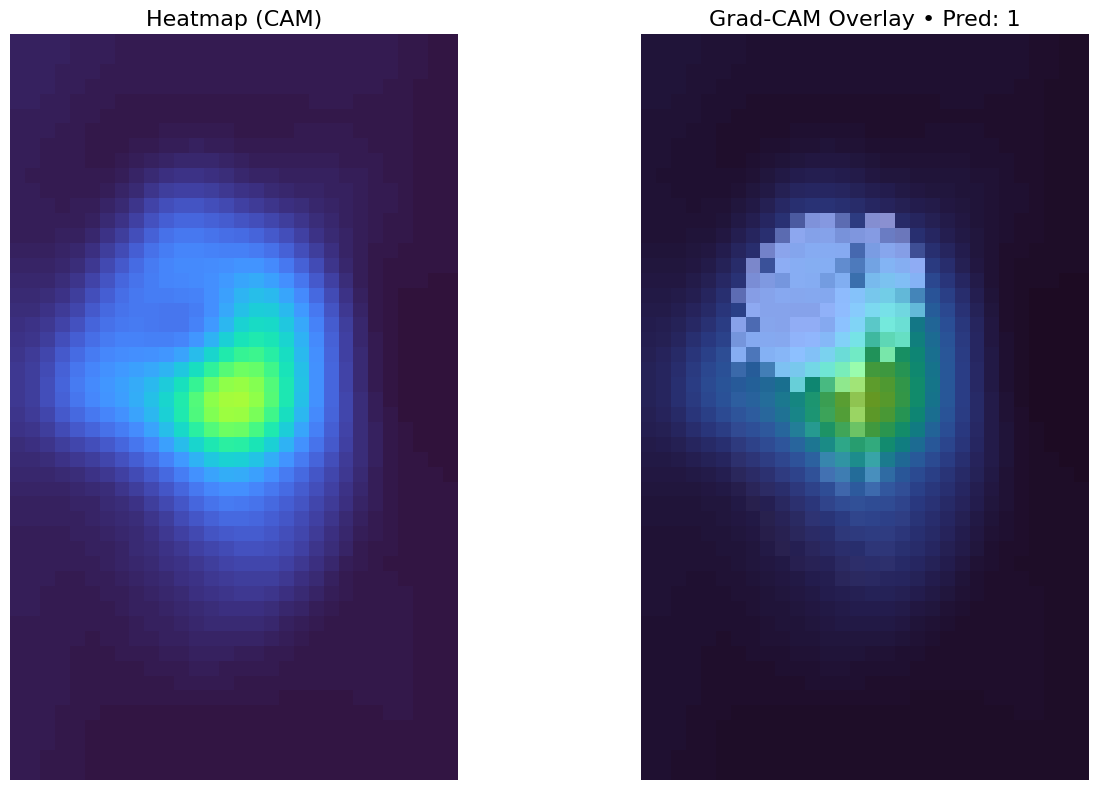

In [ ]:
# FULL  Grad-CAM SCRIPT

%matplotlib inline
import os, glob, random
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "/content/drive/MyDrive/alz_image_model_efficient3d/final_efficient3d.pth"
TEST_ROOT  = "/content/drive/MyDrive/PROCESSED_Data"
SAVE_DIR   = "/content/drive/MyDrive/alz_image_model_efficient3d"  # where saved outputs go
os.makedirs(SAVE_DIR, exist_ok=True)

print("Device:", DEVICE)
print("Model path:", MODEL_PATH)
print("Test root:", TEST_ROOT)

# -------------------- Model definition matching checkpoint shapes --------------------
class SEBlock3D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)
    def forward(self, x):
        b,c,d,h,w = x.shape
        s = x.mean(dim=(2,3,4))
        s = F.relu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s)).view(b,c,1,1,1)
        return x * s

class MBConv3D(nn.Module):
    def __init__(self, in_ch, out_ch, expand_ch, se_reduction=8, stride=1):
        super().__init__()
        # expand, bn1
        self.expand = nn.Conv3d(in_ch, expand_ch, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm3d(expand_ch)
        # depthwise conv
        self.dw = nn.Conv3d(expand_ch, expand_ch, kernel_size=3, stride=stride, padding=1, groups=expand_ch, bias=False)
        self.bn2 = nn.BatchNorm3d(expand_ch)
        # se block
        self.se = SEBlock3D(expand_ch, reduction=se_reduction)
        # project
        self.project = nn.Conv3d(expand_ch, out_ch, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm3d(out_ch)
        self.use_res = (stride == 1 and in_ch == out_ch)
    def forward(self, x):
        out = F.relu(self.bn1(self.expand(x)))
        out = F.relu(self.bn2(self.dw(out)))
        out = self.se(out)
        out = self.bn3(self.project(out))
        if self.use_res:
            return out + x
        return out

class EfficientNet3D_Matched(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # Stem: checkpoint has stem.0.weight (Conv) + stem.1 BatchNorm
        self.stem = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(32)
        )
        # Blocks: based on shapes
        # b1: in=32, expand=128, out=64, se reduction -> 128->16 means reduction=8
        self.b1 = MBConv3D(in_ch=32,  out_ch=64,  expand_ch=128, se_reduction=8, stride=1)
        # b2: in=64, expand=256, out=128
        self.b2 = MBConv3D(in_ch=64,  out_ch=128, expand_ch=256, se_reduction=8, stride=1)
        # b3: in=128, expand=512, out=256
        self.b3 = MBConv3D(in_ch=128, out_ch=256, expand_ch=512, se_reduction=8, stride=1)
        # b4: in=256, expand=1024, out=320
        self.b4 = MBConv3D(in_ch=256, out_ch=320, expand_ch=1024, se_reduction=8, stride=1)
        # b5: in=320, expand=1280, out=512
        self.b5 = MBConv3D(in_ch=320, out_ch=512, expand_ch=1280, se_reduction=8, stride=1)

        self.pool = nn.AdaptiveAvgPool3d(1)

        # FC head: checkpoint shows fc.1.weight (256x512) and fc.4.weight (3x256)
        # So create exactly: [Dropout, Linear(512,256), ReLU, Dropout, Linear(256,num_classes)]
        self.fc = nn.Sequential(
            nn.Dropout(0.4),             # fc.0 (no weights)
            nn.Linear(512, 256),         # fc.1  -> checkpoint fc.1.weight shape [256,512]
            nn.ReLU(),                   # fc.2
            nn.Dropout(0.3),             # fc.3
            nn.Linear(256, num_classes)  # fc.4  -> checkpoint fc.4.weight shape [3,256]
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        x = self.b5(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# -------------------- load model weights --------------------
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

model = EfficientNet3D_Matched(num_classes=3).to(DEVICE)

# load checkpoint (handles pure state_dict)
ck = torch.load(MODEL_PATH, map_location=DEVICE)
# if the checkpoint is nested, try to find a state_dict-like entry
if isinstance(ck, dict) and ('state_dict' in ck or 'model_state_dict' in ck):
    sd = ck.get('state_dict', ck.get('model_state_dict'))
else:
    sd = ck

# Some checkpoints might have module prefixes (like 'module.'), fix if needed
def clean_state_dict(sd):
    new = {}
    for k,v in sd.items():
        new_k = k
        if k.startswith("module."):
            new_k = k[len("module."):]
        new[new_k] = v
    return new

sd = clean_state_dict(sd)

# Load into model
missing, unexpected = model.load_state_dict(sd, strict=False)
# Print mismatch info for debugging (should be empty or only missing keys that don't matter)
print("Loaded checkpoint. Missing keys:", missing)
print("Loaded checkpoint. Unexpected keys:", unexpected)
model.eval()

# -------------------- loader that supports .npy/.nii/.nii.gz --------------------
def load_volume_any(path):
    p = str(path)
    if p.lower().endswith(".npy") or p.lower().endswith(".nii.npy"):
        vol = np.load(p).astype(np.float32)
    elif p.lower().endswith(".nii") or p.lower().endswith(".nii.gz"):
        vol = nib.load(p).get_fdata().astype(np.float32)
    else:
        raise ValueError("Unsupported file type: " + p)

    # drop extra dims if present
    if vol.ndim == 4:
        vol = vol[..., 0]

    # Some files may be stored as (H,W,D), others as (D,H,W).
    # Heuristic: if last axis is smaller than first two, assume (H,W,D) and transpose.
    if vol.shape[2] < min(vol.shape[0], vol.shape[1]):
        vol = np.transpose(vol, (2,0,1))  # (D,H,W)
    # else assume it's already (D,H,W)

    # standardize
    vol = vol.astype(np.float32)
    vol_norm = (vol - vol.mean()) / (vol.std() + 1e-6)

    # create tensor (1,1,D,H,W)
    tensor = torch.tensor(vol_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
    return tensor, vol

# -------------------- find random .nii.npy / .npy files --------------------
candidates = sorted(
    glob.glob(os.path.join(TEST_ROOT, "**", "*.nii.npy"), recursive=True)+
    glob.glob(os.path.join(TEST_ROOT, "**", "*.npy"), recursive=True) +
    glob.glob(os.path.join(TEST_ROOT, "**", "*.nii"), recursive=True) +
    glob.glob(os.path.join(TEST_ROOT, "**", "*.nii.gz"), recursive=True)
)
if len(candidates) == 0:
    raise RuntimeError("No MRI files found under TEST_ROOT: " + TEST_ROOT)

chosen = random.choice(candidates)
print("Randomly picked:", chosen)

# -------------------- Grad-CAM hooks & compute --------------------
# Target layer b5
target = model.b5
activations = None
gradients = None

def forward_hook(m, i, o):
    global activations
    activations = o.detach()

def backward_hook(m, gi, go):
    global gradients
    gradients = go[0].detach()

fh = target.register_forward_hook(forward_hook)
bh = target.register_full_backward_hook(backward_hook)

# Load volume and run model
tensor, volume = load_volume_any(chosen)   # tensor on DEVICE
with torch.no_grad():
    # but we need gradients for Grad-CAM, so enable them temporarily:
    pass

# Forward + backward
model.zero_grad()
out = model(tensor)         # logits
pred_idx = int(out.argmax(dim=1).item())

# Backprop for predicted class
# need to compute gradients: remove torch.no_grad and call backward
# ensure gradients enabled for this operation
out[0, pred_idx].backward()

# Now use activations & gradients
A = activations[0]   # (C, D, H, W)
G = gradients[0]     # (C, D, H, W)
# channel weights
weights = G.mean(dim=(1,2,3), keepdim=True)  # (C,1,1,1)
cam = (weights * A).sum(dim=0)   # (D, H, W)
cam = F.relu(cam).detach().cpu().numpy()
cam -= cam.min()
if cam.max() > 0:
    cam /= cam.max()

# choose middle axial slice
D,H,W = cam.shape
slice_idx = D // 2
heat = cam[slice_idx]
mri_slice = volume[slice_idx]

# Smooth heatmap
heat = cv2.GaussianBlur(heat, (11,11), 0)

# Colorize heatmap (convert to RGB)
heat_u8 = np.uint8(np.clip(heat,0,1)*255)
heat_color = cv2.applyColorMap(heat_u8, cv2.COLORMAP_TURBO)
heat_color = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB)

# Normalize MRI slice for display (1-99 percentile)
mn, mx = np.percentile(mri_slice, (1, 99))
mri_norm = np.clip((mri_slice - mn) / (mx - mn + 1e-6), 0, 1)
mri_u8 = np.uint8(mri_norm*255)
mri_rgb = cv2.cvtColor(mri_u8, cv2.COLOR_GRAY2RGB)

# Overlay
overlay = cv2.addWeighted(mri_rgb, 0.40, heat_color, 0.60, 0)

# -------------------- Display two-panel image (left heatmap, right overlay) --------------------
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
plt.title("Heatmap (CAM)", fontsize=16)
plt.imshow(heat_color)
plt.axis("off")

plt.subplot(1,2,2)
plt.title(f"Grad-CAM Overlay • Pred: {pred_idx}", fontsize=16)
plt.imshow(overlay)
plt.axis("off")
plt.tight_layout()
plt.show()

import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_gradcam(input_slice, heatmap, alpha=0.45, figsize=(10,5)):
    """
    input_slice: 2D numpy array (H x W) from the MRI volume
    heatmap: 2D numpy array Grad-CAM map (H x W)
    """

    # ---------------------------
    # 1. Normalize heatmap
    # ---------------------------
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # ---------------------------
    # 2. Apply smooth colormap
    # ---------------------------
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap), cv2.COLORMAP_JET
    )
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # ---------------------------
    # 3. Normalize MRI slice to 0-255
    # ---------------------------
    slice_norm = input_slice.copy()
    slice_norm = slice_norm - np.min(slice_norm)
    slice_norm = slice_norm / (np.max(slice_norm) + 1e-8)
    slice_norm = np.uint8(slice_norm * 255)

    # Convert grayscale → RGB
    slice_rgb = cv2.cvtColor(slice_norm, cv2.COLOR_GRAY2RGB)

    # ---------------------------
    # 4. Blend (overlay)
    # ---------------------------
    overlay = cv2.addWeighted(slice_rgb, 1 - alpha, heatmap_color, alpha, 0)

    # ---------------------------
    # 5. Display clean visualization
    # ---------------------------
    fig, ax = plt.subplots(1, 3, figsize=figsize)

    ax[0].imshow(slice_rgb, cmap="gray")
    ax[0].set_title("Original Slice", fontsize=14)
    ax[0].axis("off")

    ax[1].imshow(heatmap_color)
    ax[1].set_title("Grad-CAM Heatmap", fontsize=14)
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay", fontsize=14)
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

    return heatmap_color, overlay


# Remove hooks
try:
    fh.remove(); bh.remove()
except:
    pass


1. Loading Model...
   Model loaded.
2. Selecting RANDOM Test Sample...
   Randomly selected Index: 302 / 392
   Processing class: AD
3. Computing Grad-CAM...
   Success! Pred: AD (59.30%) | True: AD


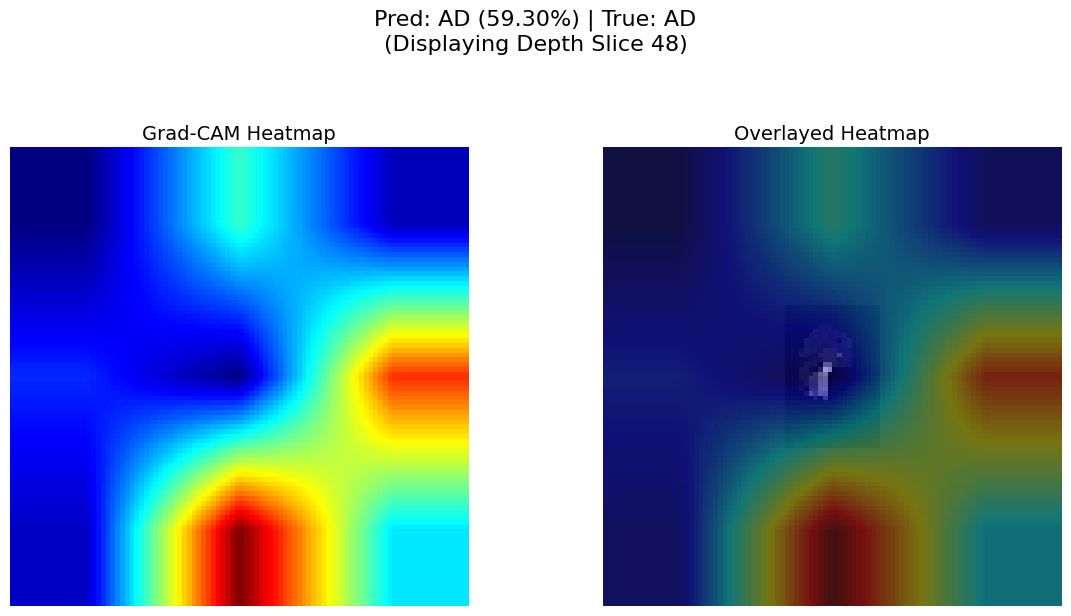

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import sys
import gc
import random

# ==========================================
# 1. RE-DEFINE MODEL (EfficientNet3D)
# ==========================================

class SEBlock3D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, d, h, w = x.shape
        s = x.mean(dim=[2, 3, 4])
        s = F.relu(self.fc1(s))
        s = torch.sigmoid(self.fc2(s)).view(b, c, 1, 1, 1)
        return x * s

class MBConv3DLite(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, expand_ratio=4):
        super().__init__()
        mid = int(in_ch * expand_ratio)
        self.expand = nn.Conv3d(in_ch, mid, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm3d(mid)
        self.dw = nn.Conv3d(mid, mid, kernel_size=3, stride=stride,
                            padding=1, groups=mid, bias=False)
        self.bn2 = nn.BatchNorm3d(mid)
        self.se = SEBlock3D(mid, reduction=8)
        self.project = nn.Conv3d(mid, out_ch, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm3d(out_ch)
        self.use_res = (stride == 1 and in_ch == out_ch)

    def forward(self, x):
        out = F.relu(self.bn1(self.expand(x)))
        out = F.relu(self.bn2(self.dw(out)))
        out = self.se(out)
        out = self.bn3(self.project(out))
        if self.use_res:
            return out + x
        return out

class EfficientNet3D(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv3d(1, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm3d(32),
            nn.ReLU(inplace=True),
        )
        self.b1 = MBConv3DLite(32, 64, stride=2)
        self.b2 = MBConv3DLite(64, 128, stride=2)
        self.b3 = MBConv3DLite(128, 256, stride=2)
        self.b4 = MBConv3DLite(256, 320, stride=1)
        self.b5 = MBConv3DLite(320, 512, stride=2) # Target Layer
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.b4(x)
        x = self.b5(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# ==========================================
# 2. GRAD-CAM FUNCTIONS
# ==========================================

def compute_gradcam_3d(model, input_array, target_layer, class_idx=None):
    device = 'cpu'
    model.eval()
    model.to(device)

    # Prepare input: (1, 1, D, H, W)
    tensor_input = torch.tensor(input_array, dtype=torch.float32).to(device)
    if tensor_input.ndim == 3:
        x = tensor_input.unsqueeze(0).unsqueeze(0)
    elif tensor_input.ndim == 4:
        x = tensor_input.permute(3, 0, 1, 2).unsqueeze(0)
    else:
        x = tensor_input

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations['value'] = out.detach()

    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    handle_forward = target_layer.register_forward_hook(forward_hook)
    handle_backward = target_layer.register_backward_hook(backward_hook)

    try:
        output = model(x)
        output_probs = F.softmax(output, dim=1)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        predicted_class_name = ["CN", "MCI", "AD"][class_idx]
        predicted_score = output_probs[0, class_idx].item()

        model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()
    except Exception as e:
        print(f"Grad-CAM Error: {e}")
        return None, None, None
    finally:
        handle_forward.remove()
        handle_backward.remove()

    grads = gradients['value']
    acts = activations['value']

    # Global Average Pooling of gradients
    weights = grads.mean(dim=(2, 3, 4), keepdim=True)

    # Weighted sum of activations
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = F.relu(cam)

    # Upsample CAM to Input Size
    cam = F.interpolate(cam, size=x.shape[2:], mode='trilinear', align_corners=False)

    gradcam_map = cam.squeeze().cpu().numpy()

    # Normalize
    if gradcam_map.max() != gradcam_map.min():
        gradcam_map = (gradcam_map - gradcam_map.min()) / (gradcam_map.max() - gradcam_map.min())
    else:
        gradcam_map = np.zeros_like(gradcam_map)

    return gradcam_map, predicted_class_name, predicted_score

def display_gradcam_custom_style(input_array, gradcam_map, prediction_text):
    input_array = input_array.squeeze()

    # Choose a middle slice (e.g., 50% of the depth) for display
    best_slice_idx = input_array.shape[0] // 2

    # Prepare images for the chosen slice
    img_slice = input_array[best_slice_idx, :, :]
    heatmap_slice = gradcam_map[best_slice_idx, :, :]

    # Normalize Image Slice for Display (0-255) and convert to BGR
    img_disp = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)
    img_disp = np.uint8(255 * img_disp)
    img_bgr = cv2.cvtColor(img_disp, cv2.COLOR_GRAY2BGR) # For overlay

    # Heatmap to Color (BGR)
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_slice), cv2.COLORMAP_JET)

    # Overlay
    overlay = cv2.addWeighted(img_bgr, 0.6, heatmap_colored, 0.4, 0)

    # Plotting: 2 Columns (Heatmap | Overlay)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Adjust y to give space between title and plots
    fig.suptitle(f"{prediction_text}\n(Displaying Depth Slice {best_slice_idx})", fontsize=16, y=1.05)

    # Plot Heatmap
    axes[0].imshow(cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Grad-CAM Heatmap", fontsize=14)
    axes[0].axis('off')

    # Plot Overlay
    axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Overlayed Heatmap", fontsize=14)
    axes[1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ==========================================
# 3. EXECUTION LOGIC (RANDOM SELECTION)
# ==========================================

classes = ["CN", "MCI", "AD"]
OUT_DIR = "/content/drive/MyDrive/alz_image_model_efficient3d"
MODEL_PATH = os.path.join(OUT_DIR, "best_efficient3d.pth")

try:
    print("1. Loading Model...")
    model = EfficientNet3D(num_classes=len(classes))

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(f"Model path incorrect: {MODEL_PATH}")

    state_dict = torch.load(MODEL_PATH, map_location='cpu')
    model.load_state_dict(state_dict)
    print("   Model loaded.")

    print("2. Selecting RANDOM Test Sample...")
    # We check if 'test_ds' (Dataset) is available from your previous cells
    if 'test_ds' in locals() or 'test_ds' in globals():
        # Pick a random index from the entire dataset
        total_samples = len(test_ds)
        random_idx = random.randint(0, total_samples - 1)

        print(f"   Randomly selected Index: {random_idx} / {total_samples}")

        # Fetch the sample directly from the dataset
        sample_vol, sample_label = test_ds[random_idx]

        # Convert tensor to numpy (Dataset returns Tensor, so we process it)
        input_vol_numpy = sample_vol.permute(1, 2, 3, 0).cpu().numpy()

        # Handle label (Dataset returns tensor)
        if torch.is_tensor(sample_label):
             true_label = classes[sample_label.item()]
        else:
             true_label = classes[sample_label]

    elif 'test_loader' in locals() or 'test_loader' in globals():
        # Fallback if direct dataset access fails but loader exists
        print("   'test_ds' not found, iterating loader to random batch...")
        random_idx = random.randint(0, len(test_loader) - 1)
        for i, batch in enumerate(test_loader):
            if i == random_idx:
                sample_vol, sample_label = batch
                input_vol_numpy = sample_vol[0].permute(1, 2, 3, 0).cpu().numpy()
                true_label = classes[sample_label[0].item()]
                break
    else:
        raise NameError("Data not found. Please run your Data Loading cell (Cell 3) first.")

    print(f"   Processing class: {true_label}")

    print("3. Computing Grad-CAM...")
    heatmap, pred_class, pred_score = compute_gradcam_3d(model, input_vol_numpy, model.b5)

    if heatmap is not None:
        text = f"Pred: {pred_class} ({pred_score:.2%}) | True: {true_label}"
        print(f"   Success! {text}")
        display_gradcam_custom_style(input_vol_numpy, heatmap, text)
    else:
        print("   Failed to generate heatmap.")

except Exception as e:
    print(f"\nERROR: {e}")
    import traceback
    traceback.print_exc()